In [14]:
import os
from analyses.data_loader import explode_spike_data
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import statsmodels.api as sm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
blah = pd.read_pickle('/old/old_analysis_cache/Zombies_significant_windows_pANOVAorGLM_passed.pkl')
blah.shape

(631, 10)

In [16]:
foo = blah[blah['PermANOVA_p-value']<0.05]
foo.shape

(43, 10)

In [17]:
results = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/Zombies_dir_ols_on_single_neurons_with_xy_values.pkl')
significant_results = results[results['p_value'] < 0.05]
print(significant_results.shape)
print(significant_results['NeuronID'].nunique())

(68, 12)
14


In [18]:
monkey_of_interest = '143H'
behavior = 'SubmissionFrom'

In [19]:
subset = results[(results['Behavior'] == behavior) & (results['Source_Monkey'] == monkey_of_interest)]
print(subset.shape)
subset_neuron_list = subset['NeuronID'].unique().tolist()
print(len(subset_neuron_list))

(15, 12)
15


In [20]:
subset

,NeuronID,Behavior,Source_Monkey,Model,R-squared,coef,intercept,p_value,p_perm,Behavior_Vector,Design_Matrix,Neural_Response
465,AMG_2023-10-04_3_Channel.C_002_Unit 1,SubmissionFrom,143H,ols,0.000010,0.002171,3.900031,0.994192,0.9938,"[0, 2, 3, 1, 2, 7, 0, 2]","[[1.0, 0.0], [1.0, 2.0], [1.0, 3.0], [1.0, 1.0...","[5.287092732834602, 3.4745326966088985, 7.2099..."
492,ER_2023-11-28_4_Channel.C_015,SubmissionFrom,143H,ols,0.018195,-0.108061,13.345198,0.750132,0.7490,"[0, 2, 3, 1, 2, 7, 0, 2]","[[1.0, 0.0], [1.0, 2.0], [1.0, 3.0], [1.0, 1.0...","[16.275686117403865, 11.225048411444115, 12.34..."
528,ER_2023-12-14_4_Channel.C_008,SubmissionFrom,143H,ols,0.019694,-0.276158,13.370764,0.740306,0.6958,"[0, 2, 3, 1, 2, 7, 0, 2]","[[1.0, 0.0], [1.0, 2.0], [1.0, 3.0], [1.0, 1.0...","[11.364899887385814, 7.544950718937052, 13.105..."
429,AMG_2023-10-04_1_Channel.C_004_Unit 1,SubmissionFrom,143H,ols,0.032916,0.179400,4.228011,0.667212,0.6454,"[0, 2, 3, 1, 2, 7, 0, 2]","[[1.0, 0.0], [1.0, 2.0], [1.0, 3.0], [1.0, 1.0...","[4.5476013288682315, 2.9089699771784803, 8.905..."
501,ER_2023-11-28_4_Channel.C_016,SubmissionFrom,143H,ols,0.037931,-0.149589,13.796569,0.643957,0.6305,"[0, 2, 3, 1, 2, 7, 0, 2]","[[1.0, 0.0], [1.0, 2.0], [1.0, 3.0], [1.0, 1.0...","[16.650715397900747, 11.4410924621918, 13.1795..."
438,AMG_2023-10-04_1_Channel.C_019_Unit 3,SubmissionFrom,143H,ols,0.057863,0.258510,5.782084,0.566070,0.5878,"[0, 2, 3, 1, 2, 7, 0, 2]","[[1.0, 0.0], [1.0, 2.0], [1.0, 3.0], [1.0, 1.0...","[5.925140413877055, 4.211864814581654, 10.0810..."
537,Unknown_2023-11-08_1_Channel.C_007,SubmissionFrom,143H,ols,0.058087,-0.170309,4.291969,0.565295,0.4444,"[0, 2, 3, 1, 2, 7, 0, 2]","[[1.0, 0.0], [1.0, 2.0], [1.0, 3.0], [1.0, 1.0...","[7.547573843638847, 2.822871564097974, 2.76229..."
447,AMG_2023-10-04_2_Channel.C_018_Unit 1,SubmissionFrom,143H,ols,0.094880,0.176155,3.056622,0.457942,0.4056,"[0, 2, 3, 1, 2, 7, 0, 2]","[[1.0, 0.0], [1.0, 2.0], [1.0, 3.0], [1.0, 1.0...","[3.5879810130735477, 1.835493260218557, 5.9690..."
411,AMG_2023-10-03_3_Channel.C_006_Unit 1,SubmissionFrom,143H,ols,0.150254,-0.502615,8.742254,0.342722,0.3269,"[0, 2, 3, 1, 2, 7, 0, 2]","[[1.0, 0.0], [1.0, 2.0], [1.0, 3.0], [1.0, 1.0...","[13.41197916496218, 10.75095076700777, 7.10073..."
474,AMG_2023-10-11_1_Channel.C_002,SubmissionFrom,143H,ols,0.175836,-0.186397,1.696883,0.301064,0.1982,"[0, 2, 3, 1, 2, 7, 0, 2]","[[1.0, 0.0], [1.0, 2.0], [1.0, 3.0], [1.0, 1.0...","[3.6602389918852416, 0.3897034328266513, 1.220..."


In [21]:
# assuming each cell has arrays/lists in 'x' and 'y' columns
X_all = pd.concat([pd.DataFrame(xi) for xi in subset['Design_Matrix']], ignore_index=True)
y_all = pd.concat([pd.Series(yi) for yi in subset['Neural_Response']], ignore_index=True)

# Fit OLS (x already includes constant)
model = sm.OLS(y_all, X_all)
fit = model.fit()

# Print results
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.3083
Date:                Tue, 02 Dec 2025   Prob (F-statistic):              0.580
Time:                        20:15:27   Log-Likelihood:                -349.71
No. Observations:                 120   AIC:                             703.4
Df Residuals:                     118   BIC:                             709.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
0              5.9585      0.586     10.170      0.0

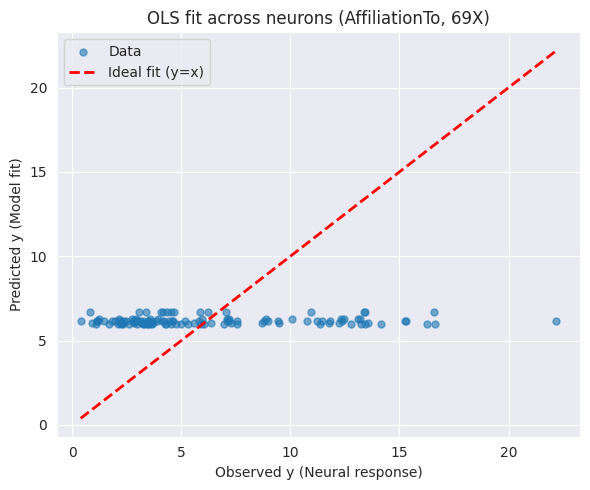

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Predicted values
y_pred = fit.predict(X_all)

# Scatter + line
plt.figure(figsize=(6, 5))
plt.scatter(y_all, y_pred, alpha=0.6, s=25, label='Data')
plt.plot([y_all.min(), y_all.max()], [y_all.min(), y_all.max()],
         'r--', lw=2, label='Ideal fit (y=x)')
plt.xlabel("Observed y (Neural response)")
plt.ylabel("Predicted y (Model fit)")
plt.title("OLS fit across neurons (AffiliationTo, 69X)")
plt.legend()
plt.tight_layout()
plt.show()


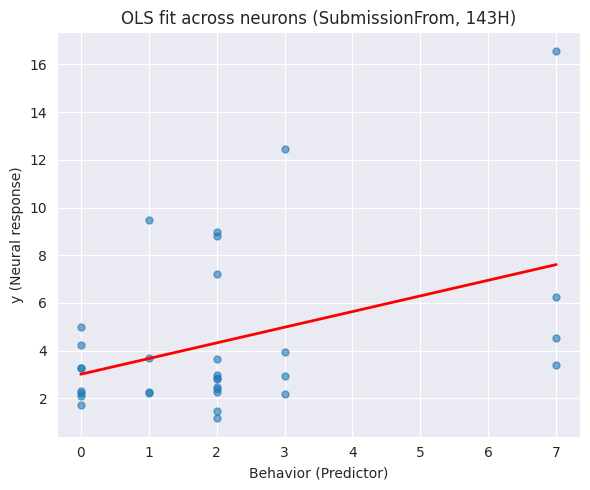

In [23]:
import matplotlib.pyplot as plt
import numpy as np

filtered_based_on_r = subset[subset['R-squared'] > 0.2]
# filtered_based_on_r = subset
# assuming each cell has arrays/lists in 'x' and 'y' columns
X_all = pd.concat([pd.DataFrame(xi) for xi in filtered_based_on_r['Design_Matrix']], ignore_index=True)
y_all = pd.concat([pd.Series(yi) for yi in filtered_based_on_r['Neural_Response']], ignore_index=True)
# print(X_all)
# Assuming x_all has one predictor column besides the constant
# If x_all has multiple predictors, pick one (e.g., x_all.iloc[:, 1])
x_vals = X_all.iloc[:, 1]  # assuming first column is constant
y_vals = y_all
# re-fit it with only the selected cells
model = sm.OLS(y_all, X_all)
fit = model.fit()

# Predicted line
x_range = np.linspace(x_vals.min(), x_vals.max(), 100)
X_plot = sm.add_constant(x_range) if 'const' not in X_all.columns else pd.DataFrame({'const': 1, X_all.columns[1]: x_range})
y_pred_line = fit.predict(X_plot)

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(x_vals, y_vals, alpha=0.6, s=25, label='Data')
plt.plot(x_range, y_pred_line, 'r-', lw=2, label='Fitted line')
plt.xlabel(f"Behavior (Predictor)")
plt.ylabel("y (Neural response)")
plt.title(f"OLS fit across neurons ({behavior}, {monkey_of_interest})")
# plt.legend()
plt.tight_layout()
plt.show()


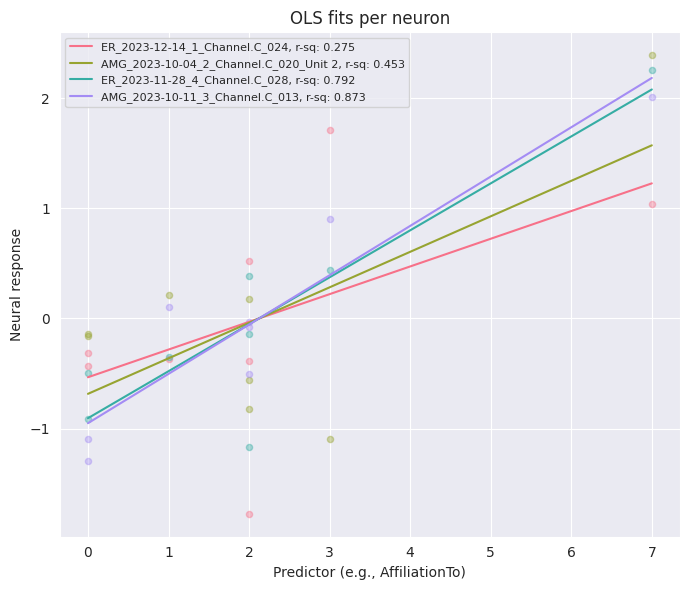

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import seaborn as sns

# Create color palette (one color per neuron)
colors = sns.color_palette("husl", len(filtered_based_on_r))

plt.figure(figsize=(7, 6))

for i, (x, y, r2, neuron) in enumerate(zip(filtered_based_on_r['Design_Matrix'],
                               filtered_based_on_r['Neural_Response'],
                               filtered_based_on_r['R-squared'],
                                filtered_based_on_r['NeuronID'])):
    # Fit OLS for this neuron (x already includes constant)
    y_norm = (y - np.mean(y)) / np.std(y)
    model = sm.OLS(y_norm, x)
    fit = model.fit()

    # Predicted line (sorted by x to make the line smooth)
    order = np.argsort(x[:, 1])  # assumes first col = constant, second = predictor
    x_sorted = x[order, 1]
    y_pred = fit.predict(x[order])

    # Plot scatter and line
    plt.scatter(x[:, 1], y_norm, color=colors[i], alpha=0.4, s=20)
    plt.plot(x_sorted, y_pred, color=colors[i], label=f"{neuron}, r-sq: {r2:.3f}", lw=1.5)

plt.xlabel("Predictor (e.g., AffiliationTo)")
plt.ylabel("Neural response")
plt.title("OLS fits per neuron")
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


In [12]:
filtered_based_on_r['Neural_Response']

519    [2.3178699136685217, 2.9792668625172594, 3.920...
456    [3.2593673586827285, 2.796841519668761, 2.1684...
510    [1.7039877872413247, 2.865167593948643, 2.9156...
483    [4.24749089204265, 8.968732149888977, 12.45902...
Name: Neural_Response, dtype: object

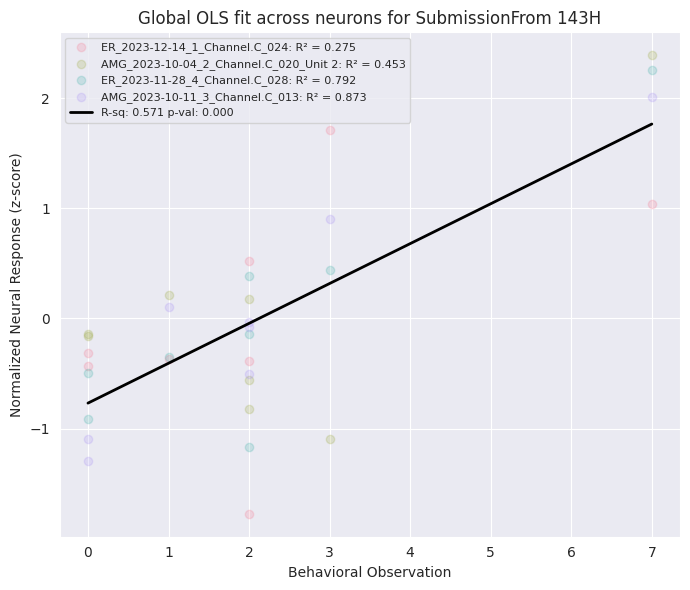

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import seaborn as sns

plt.figure(figsize=(7, 6))
colors = sns.color_palette("husl", len(filtered_based_on_r))

all_x = []
all_y = []

for i, (x, y, r2, neuron) in enumerate(zip(filtered_based_on_r['Design_Matrix'],
                                   filtered_based_on_r['Neural_Response'],
                                   filtered_based_on_r['R-squared'], filtered_based_on_r['NeuronID'])):
    # Normalize y per neuron (z-score)
    y_norm = (y - np.mean(y)) / np.std(y)
    # y_norm = y/float(np.max(y))
    # print(f"x: {x[:, 1]}")
    # print(f"y: {y_norm}")
    # Plot scatter for each neuron
    plt.scatter(x[:, 1], y_norm, color=colors[i], alpha=0.2, label=f"{neuron}: R² = {r2:.3f}")

    # Accumulate for global fit
    all_x.append(x)
    all_y.append(y_norm)

# Combine all neurons into single regression
X_all = np.vstack(all_x)
y_all = np.concatenate(all_y)
# print(y_all)
# print(X_all)
# Fit one global OLS (x already includes constant)
model = sm.OLS(y_all, X_all)
fit = model.fit()

# Generate prediction line
x_vals = np.linspace(X_all[:, 1].min(), X_all[:, 1].max(), 100)
X_pred = np.column_stack([np.ones(len(x_vals)), x_vals])  # constant + predictor
y_pred = fit.predict(X_pred)

# Plot global fit
plt.plot(x_vals, y_pred, 'k-', lw=2, label=f'R-sq: {fit.rsquared:.3f} p-val: {fit.pvalues[1]:.3f}')

plt.xlabel("Behavioral Observation")
plt.ylabel("Normalized Neural Response (z-score)")
plt.title(f"Global OLS fit across neurons for {behavior} {monkey_of_interest}")
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# print(fit.summary()

